In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import cumulative_trapezoid

## Cargar datos

In [3]:
clusters = pd.read_csv('./../data/processed/largest_clusters.csv')
members = pd.read_csv('./../data/processed/largest_clusters_members.csv')

Seleccionar el cúmulo y sus miembros.

In [4]:
cluster_name = 'NGC_3201'
cluster = clusters[clusters['Name'] == cluster_name]
cluster_members = members[members['Name'] == cluster_name]

Seleccionar coordenadas y distancia al cúmulo.

In [5]:
ra0 = float(cluster['RA_ICRS'].values[0]) # grados
dec0 = float(cluster['DE_ICRS'].values[0]) # grados
d0 = float(cluster['dist50'].values[0])  # pc

Seleccionar coordenadas y masas de las estrellas del cúmulo.

In [6]:
ras = cluster_members['RA_ICRS'].values # grados
decs = cluster_members['DE_ICRS'].values # grados
Ms = cluster_members['Mass50'].values  # M_sun
M_mean = np.mean(Ms)
M_tot = np.sum(Ms)

## Proyección al plano tangente

Realizar proyección al plano tangente.

In [7]:
X, Y = utils.tangent_plane_projection(ras, decs, ra0, dec0, d0)

Calcular radios superficiales del cúmulo.

In [8]:
Rs = np.sqrt(X**2 + Y**2)

## Ajuste del perfil de densidad superficial

Calcular la densidad de número superficial observada.

In [9]:
def calculate_num_surface_density(Rs, num_bins=30):
    counts, bin_edges = np.histogram(Rs, bins=num_bins)
    areas = np.pi * (bin_edges[1:]**2 - bin_edges[:-1]**2)

    Rs_mid = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    Sigma_obs = counts / areas
    return Rs_mid, Sigma_obs

Definir número de bines.

In [10]:
N = len(Rs)
num_bins = int(np.sqrt(N))

In [11]:
Rs_mid, Sigma_obs = calculate_num_surface_density(Rs, num_bins)

Estimaciones iniciales.

In [12]:
k_guess = np.max(Sigma_obs)
rc_guess = np.median(Rs) * 0.5
rt_guess = np.max(Rs)

Realizar ajuste.

In [13]:
popt_2d, pcov_2d = curve_fit(
    utils.num_surface_density,
    Rs_mid, Sigma_obs,
    p0=[rc_guess, rt_guess, k_guess],
    bounds=(0, np.inf),
    maxfev=10000,
)

### Valores obtenidos

In [14]:
rc_2d, rt_2d, k_2d = popt_2d
perr_2d = np.sqrt(np.diag(pcov_2d))

print(f"[2D] rc = {rc_2d:.3f} ± {perr_2d[0]:.3f} pc")
print(f"[2D] rt = {rt_2d:.3f} ± {perr_2d[1]:.3f} pc")
print(f"[2D] k  = {k_2d:.4g} ± {perr_2d[2]:.4g}")

[2D] rc = 6.753 ± 0.098 pc
[2D] rt = 56.166 ± 2.546 pc
[2D] k  = 108.8 ± 1.583


## Ajuste del perfil de densidad espacial de número

Realizar rejection sampling.

In [15]:
Z = utils.rejection_sampling(Rs, rc_2d, rt_2d, k_2d, seed=23)

Quitar valores que no sea finitos.

In [16]:
valid_mask = np.isfinite(Z)
X_v = X[valid_mask]
Y_v = Y[valid_mask]
Z_v = Z[valid_mask]
Ms_v = Ms[valid_mask]

Calcular radios espaciales.

In [17]:
rs = np.sqrt(X_v**2 + Y_v**2 + Z_v**2)

Calcular densidad de número espacial observada.

In [18]:
def calculate_num_density(rs, num_bins=30):
    counts, bin_edges = np.histogram(rs, bins=num_bins)
    vols = (4.0/3.0) * np.pi * (bin_edges[1:]**3 - bin_edges[:-1]**3)
    
    rs_mid = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    n_obs = counts / vols
    return rs_mid, n_obs

Definir número de bines.

In [19]:
N = len(rs)
num_bins = int(np.sqrt(N))

In [20]:
rs_mid, n_obs = calculate_num_density(rs, num_bins)

Realizar ajuste.

In [21]:
popt_3d, pcov_3d = curve_fit(
    utils.num_density,
    rs_mid, n_obs,
    p0=[rc_2d, rt_2d, k_2d], # se usa el ajuste 2D
    bounds=(0, np.inf),
    maxfev=10000,
)

### Valores obtenidos

In [22]:
rc_3d, rt_3d, k_3d = popt_3d
perr_3d = np.sqrt(np.diag(pcov_3d))

print(f"\n[3D] rc = {rc_3d:.3f} ± {perr_3d[0]:.3f} pc")
print(f"[3D] rt = {rt_3d:.3f} ± {perr_3d[1]:.3f} pc")
print(f"[3D] k  = {k_3d:.4g} ± {perr_3d[2]:.4g}")


[3D] rc = 7.200 ± 0.211 pc
[3D] rt = 35.560 ± 6.025 pc
[3D] k  = 130.7 ± 11.08


## Dispersión de velocidades teórica usando el modelo de King 3D

Masa acumulada teórica

In [23]:
def mass_accum(rs, M_mean, rc, rt, k):
    """
    Masa acumulada M(<r) usando densidad de masa rho(r) = M_mean · n(r).
 
    Parámetros con unidades:
      rs     — parsecs
      M_mean — M_sun
      k      — parámetro de normalización de n(r)
    Retorna M(<r) en M_sun.
    """

    rhos = M_mean * utils.num_density(rs, rc, rt, k) # M_sun / pc^3
    integrand = rs**2 * rhos
    M_r = 4.0 * np.pi * cumulative_trapezoid(integrand, rs, initial=0)
    return M_r

Dispersión de velocidades.

In [24]:
def calculate_sig2(rs, M_mean, rc, rt, k):
    """
    Dispersión de velocidades al cuadrado σ²(r) [km²/s²] por el ecuación
    de Jeans isotrópica en equilibrio.
    """
    G = 4.300e-3 # pc M_sun^-1 (km/s)^2
 
    rhos = M_mean * utils.num_density(rs, rc, rt, k)
    rhos_safe = np.where(rhos > 0.0, rhos, np.nan)
    M_r = mass_accum(rs, M_mean, rc, rt, k)
 
    integrand = rhos_safe * M_r / rs**2
    valid = np.isfinite(integrand)
    integrand_filled = np.where(valid, integrand, 0.0)
 
    int_0_r = cumulative_trapezoid(integrand_filled, rs, initial=0)
    int_r_rt = int_0_r[-1] - int_0_r
 
    sig2 = np.where(rhos_safe > 0.0, G / rhos_safe * int_r_rt, 0.0)
    return sig2

## Ajuste de la dispersión de velocidades observada

Calcular dispersión de velocidades observada.

In [25]:
def calculate_sig2_obs(rs, Ms, num_bins=30, min_stars=3):
    """
    Dispersión de velocidades observada por bins usando la ecuación de Jeans.
 
    Parámetros
    ----------
    rs: radios 3D de los miembros válidos (pc)
    Ms: masas de los miembros válidos (M_sun)
    rc: parámetros del ajuste 3D de King
    """

    G = 4.300e-3 # pc * M_sun^-1 * (km/s)^2
 
    rs_bins = np.linspace(np.min(rs), np.max(rs), num_bins + 1)
    rs_mid = 0.5 * (rs_bins[1:] + rs_bins[:-1])
 
    rs_mid_valid = []
    rhos_list = []
    M_acc_bin = []
 
    for i in range(num_bins):
        in_bin = (rs >= rs_bins[i]) & (rs < rs_bins[i + 1])
        num_stars = np.sum(in_bin)
 
        if num_stars < min_stars:
            continue
 
        vol = (4.0/3.0) * np.pi * (rs_bins[i+1]**3 - rs_bins[i]**3)
        mass_in_bin = np.sum(Ms[in_bin])
        rho = mass_in_bin / vol
 
        rs_mid_valid.append(rs_mid[i])
        rhos_list.append(rho)
        M_acc_bin.append(mass_in_bin)
 
    rs_mid_valid = np.array(rs_mid_valid)
    rhos = np.array(rhos_list)
    M_acc_bin = np.cumsum(M_acc_bin)
 
    # Integral de Jeans
    integrand = rhos * M_acc_bin / rs_mid_valid**2
    int_0_r = cumulative_trapezoid(integrand, rs_mid_valid, initial=0)
    int_r_rt = int_0_r[-1] - int_0_r
 
    sig2 = G / rhos * int_r_rt
    return rs_mid_valid, sig2

In [26]:
rs_mid_sig2, sig2_obs = calculate_sig2_obs(rs, Ms_v, num_bins)

Realizar ajuste.

In [27]:
def sig2_model_for_fit(rs_obs, M_mean, rc, rt, k):
    """
    Envolvente de calculate_sig2 para curve_fit.
 
    Evalúa sig^2(r) sobre un grid denso y luego interpola en los puntos 
    observados rs_obs.
    """

    # Grid interno denso
    r_min = max(0.01 * rc, 1e-3)
    r_max = max(rt, np.max(rs_obs) * 1.05)
    rs_grid = np.linspace(r_min, r_max, 2000)
 
    sig2_grid = calculate_sig2(rs_grid, M_mean, rc, rt, k)
 
    # Interpolación lineal en los puntos observados
    sig2_interp = np.interp(rs_obs, rs_grid, sig2_grid)
    return sig2_interp

In [28]:
p0_fit = [M_mean, rc_3d, rt_3d, k_3d]

bounds_fit = (
    [np.min(Ms_v) * 0.1, 0.01, 0.01, 1e-6],
    [np.max(Ms_v) * 10,  np.inf, np.inf, np.inf],
)

popt_sig2, pcov_sig2 = curve_fit(
    sig2_model_for_fit,
    rs_mid_sig2, sig2_obs,
    p0=p0_fit,
    bounds=bounds_fit,
    maxfev=10000,
)

### Valores obtenidos

In [29]:
M_mean_fit, rc_sig2, rt_sig2, k_sig2 = popt_sig2
perr_sig2 = np.sqrt(np.diag(pcov_sig2))

print(f"\n[sig^2 fit] M_mean = {M_mean_fit:.3f} ± {perr_sig2[0]:.3f} M_sun")
print(f"[sig^2 fit] rc     = {rc_sig2:.3f} ± {perr_sig2[1]:.3f} pc")
print(f"[sig^2 fit] rt     = {rt_sig2:.3f} ± {perr_sig2[2]:.3f} pc")


[sig^2 fit] M_mean = 1.981 ± 1861621.257 M_sun
[sig^2 fit] rc     = 3.374 ± 0.209 pc
[sig^2 fit] rt     = 69.649 ± 2.133 pc


## Resumen de parámetros

In [30]:
print("\n" + "="*55)
print("RESUMEN DE PARÁMETROS DE KING")
print("="*55)
print(f"{'Etapa':<35} {'rc [pc]':>8} {'rt [pc]':>10}")
print("-"*55)
print(f"{'Ajuste superficial (2D)':<35} {rc_2d:>8.3f} {rt_2d:>10.3f}")
print(f"{'Ajuste espacial (3D)':<35} {rc_3d:>8.3f} {rt_3d:>10.3f}")
print(f"{'Ajuste sigma^2(r)':<35} {rc_sig2:>8.3f} {rt_sig2:>10.3f}")
print("="*55)


RESUMEN DE PARÁMETROS DE KING
Etapa                                rc [pc]    rt [pc]
-------------------------------------------------------
Ajuste superficial (2D)                6.753     56.166
Ajuste espacial (3D)                   7.200     35.560
Ajuste sigma^2(r)                      3.374     69.649


## Perfiles obtenidos

Calcular radios y densidad superficial teóricos usando el perfil de densidad superficial de número de King.

In [31]:
Rs_theo = np.linspace(0.01 * rc_2d, rt_2d, 300)
Sigma_theo = utils.num_surface_density(Rs_theo, rc_2d, rt_2d, k_2d)

Calcular radios, densidad espacial y masa acumulada teóricos usando el perfil de densidad espacial de número de King.

In [32]:
rs_theo = np.linspace(0.01 * rc_3d, rt_3d, 2000)
n_theo = utils.num_density(rs_theo, rc_3d, rt_3d, k_3d)
M_accum_theo = mass_accum(rs_theo, M_mean, rc_3d, rt_3d, k_3d)
sig2_theo = calculate_sig2(rs_theo, M_mean, rc_3d, rt_3d, k_3d)

Calcular radios y dispersión de velocidades teóricos obtenido del ajuste de dispersión de velocidades.

In [33]:
rs_theo_sig2 = np.linspace(0.01 * rc_sig2, rt_sig2, 2000)
sig2_theo_fit = calculate_sig2(rs_theo_sig2, M_mean_fit, rc_sig2, rt_sig2, k_sig2)

### Graficas obtenidas

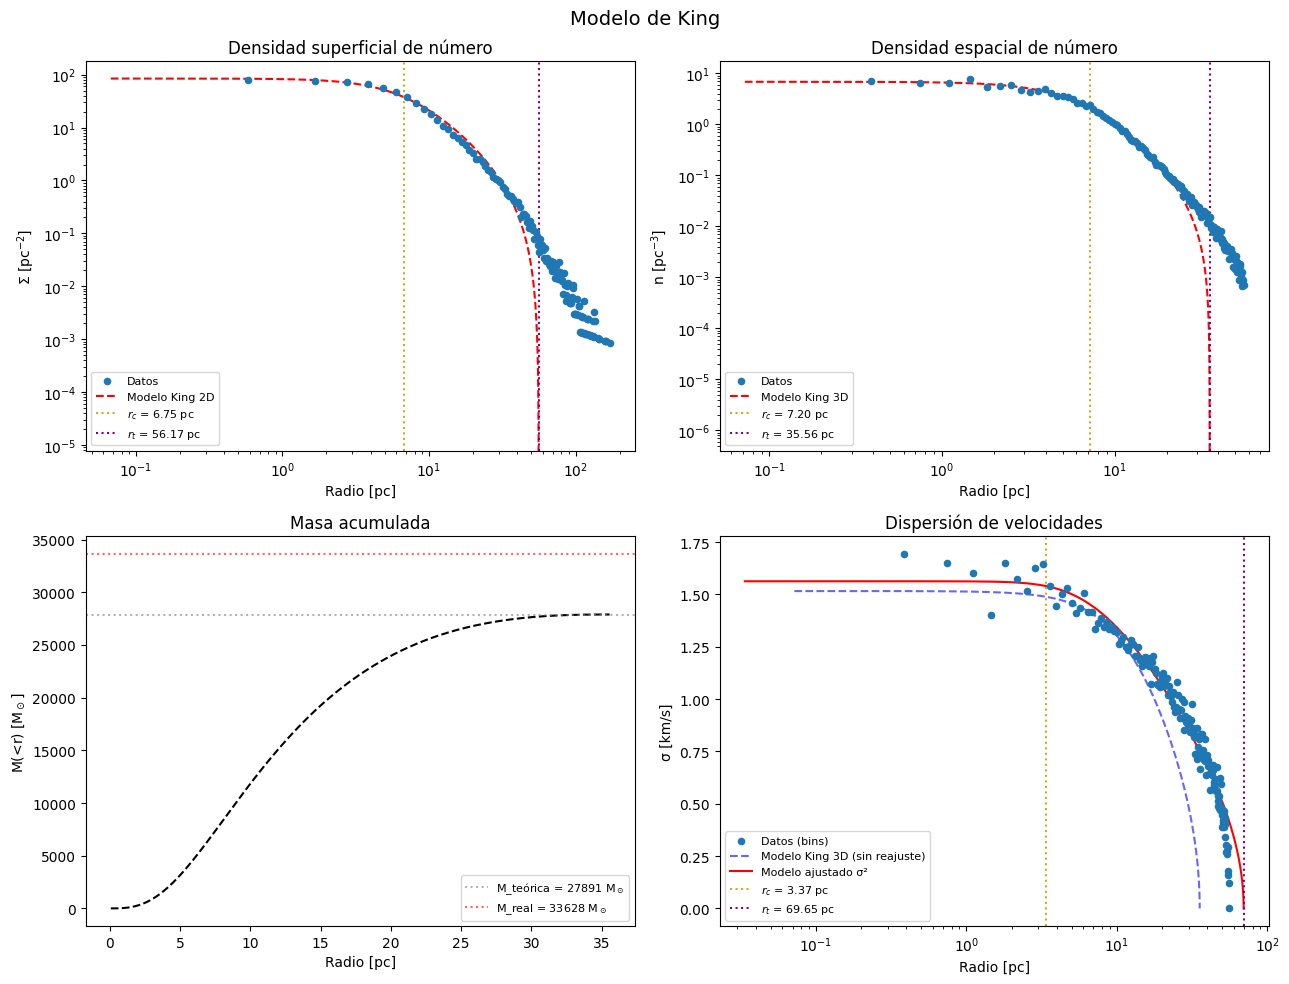

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle("Modelo de King", fontsize=14)

# --- Densidad superficial de número -------------------------------------------

ax = axes[0, 0]
ax.set_title("Densidad superficial de número")
ax.scatter(Rs_mid, Sigma_obs, s=20, label="Datos", zorder=3)
ax.plot(Rs_theo, Sigma_theo, "r--", label="Modelo King 2D")
ax.axvline(rc_2d, color="goldenrod", ls=":", label=f"$r_c$ = {rc_2d:.2f} pc")
ax.axvline(rt_2d, color="purple", ls=":", label=f"$r_t$ = {rt_2d:.2f} pc")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Radio [pc]"); ax.set_ylabel("Σ [pc$^{-2}$]")
ax.legend(fontsize=8)

# --- Densidad espacial de número ----------------------------------------------

ax = axes[0, 1]
ax.set_title("Densidad espacial de número")
ax.scatter(rs_mid, n_obs, s=20, label="Datos", zorder=3)
ax.plot(rs_theo, n_theo, "r--", label="Modelo King 3D")
ax.axvline(rc_3d, color="goldenrod", ls=":", label=f"$r_c$ = {rc_3d:.2f} pc")
ax.axvline(rt_3d, color="purple", ls=":", label=f"$r_t$ = {rt_3d:.2f} pc")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Radio [pc]"); ax.set_ylabel("n [pc$^{-3}$]")
ax.legend(fontsize=8)

# --- Masa acumulada -----------------------------------------------------------

ax = axes[1, 0]
ax.set_title("Masa acumulada")
ax.plot(rs_theo, M_accum_theo, "k--")
ax.set_xlabel("Radio [pc]"); ax.set_ylabel("M(<r) [M$_\\odot$]")
ax.axhline(M_accum_theo[-1], color="gray", ls=":", alpha=0.6,
           label=f"M_teórica = {M_accum_theo[-1]:.0f} M$_\\odot$")
ax.axhline(M_tot, color="red", ls=":", alpha=0.6, 
           label=f"M_real = {M_tot:.0f} M$_\\odot$")
ax.legend(fontsize=8)

# --- Dispersión de velocidades ------------------------------------------------

ax = axes[1, 1]
ax.set_title("Dispersión de velocidades")
ax.scatter(rs_mid_sig2, np.sqrt(np.clip(sig2_obs, 0, None)),
           s=20, label="Datos (bins)", zorder=3)
ax.plot(rs_theo, np.sqrt(np.clip(sig2_theo, 0, None)),
        "b--", label="Modelo King 3D (sin reajuste)", alpha=0.6)
ax.plot(rs_theo_sig2, np.sqrt(np.clip(sig2_theo_fit, 0, None)),
        "r-", label="Modelo ajustado σ²")
ax.axvline(rc_sig2, color="goldenrod", ls=":",
           label=f"$r_c$ = {rc_sig2:.2f} pc")
ax.axvline(rt_sig2, color="purple",    ls=":",
           label=f"$r_t$ = {rt_sig2:.2f} pc")
ax.set_xscale("log")
ax.set_xlabel("Radio [pc]"); ax.set_ylabel("σ [km/s]")
ax.legend(fontsize=8)
 
plt.tight_layout()
plt.show()